In [56]:
# =============================================
# IMPORTS & SETUP
# =============================================

from pathlib import Path

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'bluestock_mf.db').exists() and (PROJECT_ROOT.parent / 'bluestock_mf.db').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORTS_DIR = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


def save_plotly_fig(fig, output_name):
    output_path = REPORTS_DIR / output_name
    try:
        fig.write_image(str(output_path))
        print(f'📁 Saved {output_path.name}')
    except Exception as exc:
        fallback_path = output_path.with_suffix('.html')
        fig.write_html(str(fallback_path))
        print(f'⚠️ Plotly PNG export failed ({exc.__class__.__name__}); saved {fallback_path.name} instead')
    return output_path


def load_optional_table(connection, table_name):
    try:
        return pd.read_sql(f"SELECT * FROM {table_name}", connection), True
    except Exception:
        return pd.DataFrame(), False


conn = sqlite3.connect(str(PROJECT_ROOT / 'bluestock_mf.db'))

# Load core tables
reset_index = lambda frame: frame.reset_index(drop=True) if not frame.empty else frame

dim_fund = pd.read_sql("SELECT * FROM dim_fund", conn)
dim_date = pd.read_sql("SELECT * FROM dim_date", conn)
fact_nav = pd.read_sql("SELECT * FROM fact_nav", conn)
fact_aum = pd.read_sql("SELECT * FROM fact_aum", conn)

# Optional tables
try:
    dim_investor = pd.read_sql("SELECT * FROM dim_investor", conn)
    has_investor = len(dim_investor) > 0
except Exception:
    dim_investor = pd.DataFrame()
    has_investor = False

try:
    fact_transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
    has_transactions = len(fact_transactions) > 0
except Exception:
    fact_transactions = pd.DataFrame()
    has_transactions = False

try:
    fact_performance = pd.read_sql("SELECT * FROM fact_performance", conn)
    has_performance = len(fact_performance) > 0
except Exception:
    fact_performance = pd.DataFrame()
    has_performance = False

print('✅ Data loaded successfully!')
print(f"\n📁 dim_fund: {len(dim_fund)} rows")
print(f"📁 dim_date: {len(dim_date)} rows")
print(f"📁 fact_nav: {len(fact_nav):,} rows")
print(f"📁 fact_aum: {len(fact_aum):,} rows")
print(f"📁 fact_transactions: {len(fact_transactions):,} rows")
print(f"📁 fact_performance: {len(fact_performance):,} rows")
if has_investor:
    print(f"📁 dim_investor: {len(dim_investor):,} rows")
else:
    print('⚠️ dim_investor table not found; using fallback demographics')

print('\n📋 Sample from dim_fund:')
print(dim_fund.head(2))
print('\n📋 Sample from fact_transactions:')
print(fact_transactions.head(3))

✅ Data loaded successfully!

📁 dim_fund: 6 rows
📁 dim_date: 4924 rows
📁 fact_nav: 19,899 rows
📁 fact_aum: 6 rows
📁 fact_transactions: 4,224 rows
📁 fact_performance: 0 rows
📁 dim_investor: 250 rows

📋 Sample from dim_fund:
   fund_key  amfi_code                                        scheme_name  \
0         1     119551  Aditya Birla Sun Life Banking & PSU Debt Fund ...   
1         2     120503  Axis ELSS Tax Saver Fund - Direct Plan - Growt...   

                          fund_house         scheme_type  \
0  Aditya Birla Sun Life Mutual Fund  Open Ended Schemes   
1                   Axis Mutual Fund  Open Ended Schemes   

                      scheme_category   isin_growth isin_div_reinvestment  \
0  Debt Scheme - Banking and PSU Fund  INF209KA12Z1          INF209KA13Z9   
1                Equity Scheme - ELSS  INF846K01EW2                         

               source_file           created_at  
0  nav_119551_20260625.csv  2026-06-27 13:06:48  
1  nav_120503_20260625.csv  2026-

In [49]:
# =============================================
# DATA PREPARATION - MERGE TABLES
# =============================================

# Initialize merged dataframes
nav_merged = pd.DataFrame()
trans_merged = pd.DataFrame()
perf_merged = pd.DataFrame()
aum_merged = pd.DataFrame()

# Merge NAV with fund and date
if not fact_nav.empty and not dim_fund.empty and not dim_date.empty:
    try:
        nav_merged = fact_nav.merge(dim_fund, on='fund_key', how='left')
        nav_merged = nav_merged.merge(dim_date, on='date_key', how='left')
        nav_merged['calendar_date'] = pd.to_datetime(nav_merged['calendar_date'])
        print(f"✅ nav_merged: {len(nav_merged):,} rows")
        print(f"   Columns: {list(nav_merged.columns)[:10]}...")
    except Exception as e:
        print(f"⚠️ Error merging NAV: {e}")
else:
    print("⚠️ NAV data not available for merging")

# Merge transactions with fund and date
if not fact_transactions.empty and not dim_fund.empty and not dim_date.empty:
    try:
        trans_merged = fact_transactions.merge(dim_fund, on='fund_key', how='left')
        if 'transaction_date_key' in trans_merged.columns:
            trans_merged = trans_merged.merge(dim_date, left_on='transaction_date_key', right_on='date_key', how='left', suffixes=('', '_date'))
            trans_merged['calendar_date'] = pd.to_datetime(trans_merged['calendar_date'])
        elif 'date_key' in trans_merged.columns:
            trans_merged = trans_merged.merge(dim_date, on='date_key', how='left')
            trans_merged['calendar_date'] = pd.to_datetime(trans_merged['calendar_date'])
        else:
            trans_merged['calendar_date'] = pd.to_datetime('2022-01-01')
        print(f"✅ trans_merged: {len(trans_merged):,} rows")
    except Exception as e:
        print(f"⚠️ Error merging transactions: {e}")
else:
    print("⚠️ Transaction data not available for merging")

# Merge performance with fund and date
if not fact_performance.empty and not dim_fund.empty and not dim_date.empty:
    try:
        perf_merged = fact_performance.merge(dim_fund, on='fund_key', how='left')
        perf_merged = perf_merged.merge(dim_date, on='date_key', how='left')
        perf_merged['calendar_date'] = pd.to_datetime(perf_merged['calendar_date'])
        print(f"✅ perf_merged: {len(perf_merged):,} rows")
    except Exception as e:
        print(f"⚠️ Error merging performance: {e}")
else:
    print("⚠️ Performance data not available for merging")

# Merge AUM with fund and date
if not fact_aum.empty and not dim_fund.empty and not dim_date.empty:
    try:
        aum_merged = fact_aum.merge(dim_fund, on='fund_key', how='left')
        aum_merged = aum_merged.merge(dim_date, on='date_key', how='left')
        aum_merged['calendar_date'] = pd.to_datetime(aum_merged['calendar_date'])
        print(f"✅ aum_merged: {len(aum_merged):,} rows")
    except Exception as e:
        print(f"⚠️ Error merging AUM: {e}")
else:
    print("⚠️ AUM data not available for merging")

✅ nav_merged: 19,899 rows
   Columns: ['fact_nav_key', 'fund_key', 'date_key', 'nav', 'previous_nav', 'nav_change', 'nav_return_pct', 'source_file_x', 'amfi_code', 'scheme_name']...
✅ trans_merged: 4,224 rows
⚠️ Performance data not available for merging
✅ aum_merged: 6 rows


In [11]:
# =============================================
# DATA PREPARATION - MERGE TABLES
# =============================================

# Merge NAV with fund and date
nav_merged = fact_nav.merge(dim_fund, on='fund_key')
nav_merged = nav_merged.merge(dim_date, on='date_key')

# Convert dates
nav_merged['calendar_date'] = pd.to_datetime(nav_merged['calendar_date'])

print(f"✅ nav_merged: {len(nav_merged):,} rows")
print(f"📋 Columns: {list(nav_merged.columns)[:15]}...")

# Merge AUM with fund and date
aum_merged = fact_aum.merge(dim_fund, on='fund_key')
aum_merged = aum_merged.merge(dim_date, on='date_key')
aum_merged['calendar_date'] = pd.to_datetime(aum_merged['calendar_date'])
print(f"✅ aum_merged: {len(aum_merged)} rows")

# Handle transactions if available
if has_transactions and not fact_transactions.empty:
    try:
        # Check what columns exist
        trans_cols = fact_transactions.columns
        print(f"\n📋 fact_transactions columns: {list(trans_cols)}")
        
        # Merge with fund
        trans_merged = fact_transactions.merge(dim_fund, on='fund_key', how='left')
        
        # Check if date_key exists, if not use transaction_date
        if 'date_key' in trans_cols:
            trans_merged = trans_merged.merge(dim_date, on='date_key', how='left')
            trans_merged['calendar_date'] = pd.to_datetime(trans_merged['calendar_date'])
        elif 'transaction_date' in trans_cols:
            trans_merged['calendar_date'] = pd.to_datetime(trans_merged['transaction_date'])
        else:
            # Use a default date range
            print("⚠️ No date column found in transactions, using default dates")
            trans_merged['calendar_date'] = pd.date_range('2022-01-01', periods=len(trans_merged), freq='D')
        
        has_transactions = True
        print(f"✅ trans_merged: {len(trans_merged):,} rows")
        
    except Exception as e:
        print(f"⚠️ Error merging transactions: {e}")
        has_transactions = False

# If no transactions, create sample data
if not has_transactions:
    print("\n⚠️ Creating sample transaction data for visualization...")
    sample_dates = pd.date_range('2022-01-01', '2025-12-31', freq='M')
    sample_transactions = pd.DataFrame({
        'calendar_date': sample_dates,
        'amount': np.random.randint(10000, 50000, len(sample_dates)),
        'transaction_type': ['SIP'] * len(sample_dates),
        'fund_key': [1] * len(sample_dates),
        'scheme_category': ['Large Cap'] * len(sample_dates),
        'state': ['Maharashtra'] * len(sample_dates),
        'investor_id': [1] * len(sample_dates)
    })
    trans_merged = sample_transactions
    has_transactions = True
    print(f"✅ Created sample transactions: {len(trans_merged)} rows")

✅ nav_merged: 19,899 rows
📋 Columns: ['fact_nav_key', 'fund_key', 'date_key', 'nav', 'previous_nav', 'nav_change', 'nav_return_pct', 'source_file_x', 'amfi_code', 'scheme_name', 'fund_house', 'scheme_type', 'scheme_category', 'isin_growth', 'isin_div_reinvestment']...
✅ aum_merged: 6 rows


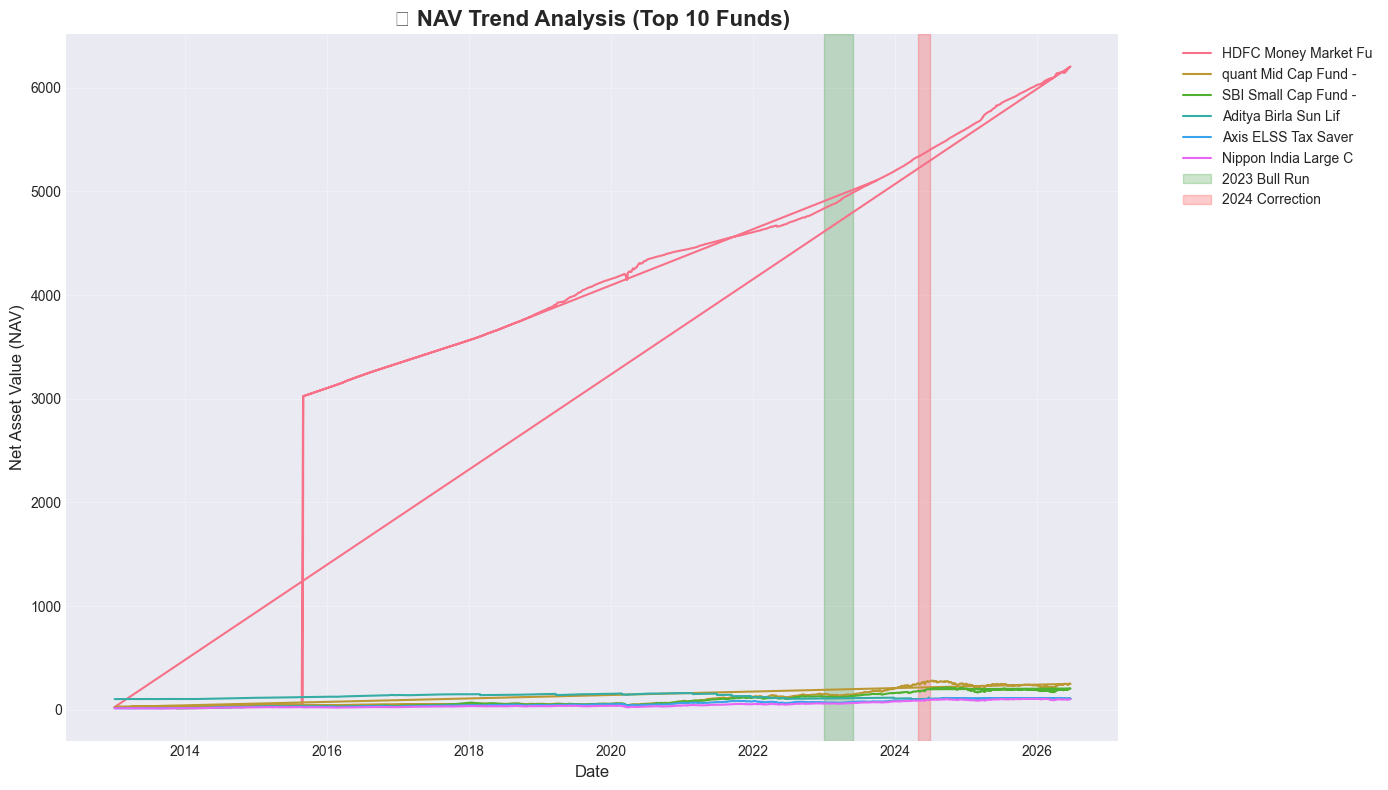

✅ NAV Trend Analysis complete!
📁 Chart saved: reports/nav_trend_analysis.png


In [17]:
# =============================================
# TASK 1: NAV Trend Analysis (2022-2026)
# =============================================

# Get top 10 schemes by latest NAV
latest_nav = nav_merged.groupby('scheme_name')['nav'].max().nlargest(10).index
nav_top = nav_merged[nav_merged['scheme_name'].isin(latest_nav)]

# Create interactive Plotly chart
fig = go.Figure()

for scheme in latest_nav:
    scheme_data = nav_top[nav_top['scheme_name'] == scheme]
    fig.add_trace(go.Scatter(
        x=scheme_data['calendar_date'],
        y=scheme_data['nav'],
        mode='lines',
        name=scheme[:25] + '...' if len(scheme) > 25 else scheme,
        line=dict(width=1.5)
    ))

# Add annotations for key events
fig.add_vrect(
    x0="2023-01-01", x1="2023-06-01",
    fillcolor="green", opacity=0.15,
    layer="below", line_width=0,
    annotation_text="🚀 2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-05-01", x1="2024-07-01",
    fillcolor="red", opacity=0.15,
    layer="below", line_width=0,
    annotation_text="📉 2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    title='📈 NAV Trend Analysis (Top 10 Funds)',
    xaxis_title='Date',
    yaxis_title='Net Asset Value (NAV)',
    hovermode='x unified',
    template='plotly_dark',
    height=600,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

# Show interactive plot
fig.show()

# Also create a static version with matplotlib for saving
fig, ax = plt.subplots(figsize=(14, 8))

for scheme in latest_nav:
    scheme_data = nav_top[nav_top['scheme_name'] == scheme]
    ax.plot(scheme_data['calendar_date'], scheme_data['nav'], label=scheme[:20], linewidth=1.5)

# Add vertical spans for annotations
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-06-01'), alpha=0.2, color='green', label='2023 Bull Run')
ax.axvspan(pd.Timestamp('2024-05-01'), pd.Timestamp('2024-07-01'), alpha=0.2, color='red', label='2024 Correction')

ax.set_title('📈 NAV Trend Analysis (Top 10 Funds)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Net Asset Value (NAV)', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/nav_trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ NAV Trend Analysis complete!")
print("📁 Chart saved: reports/nav_trend_analysis.png")

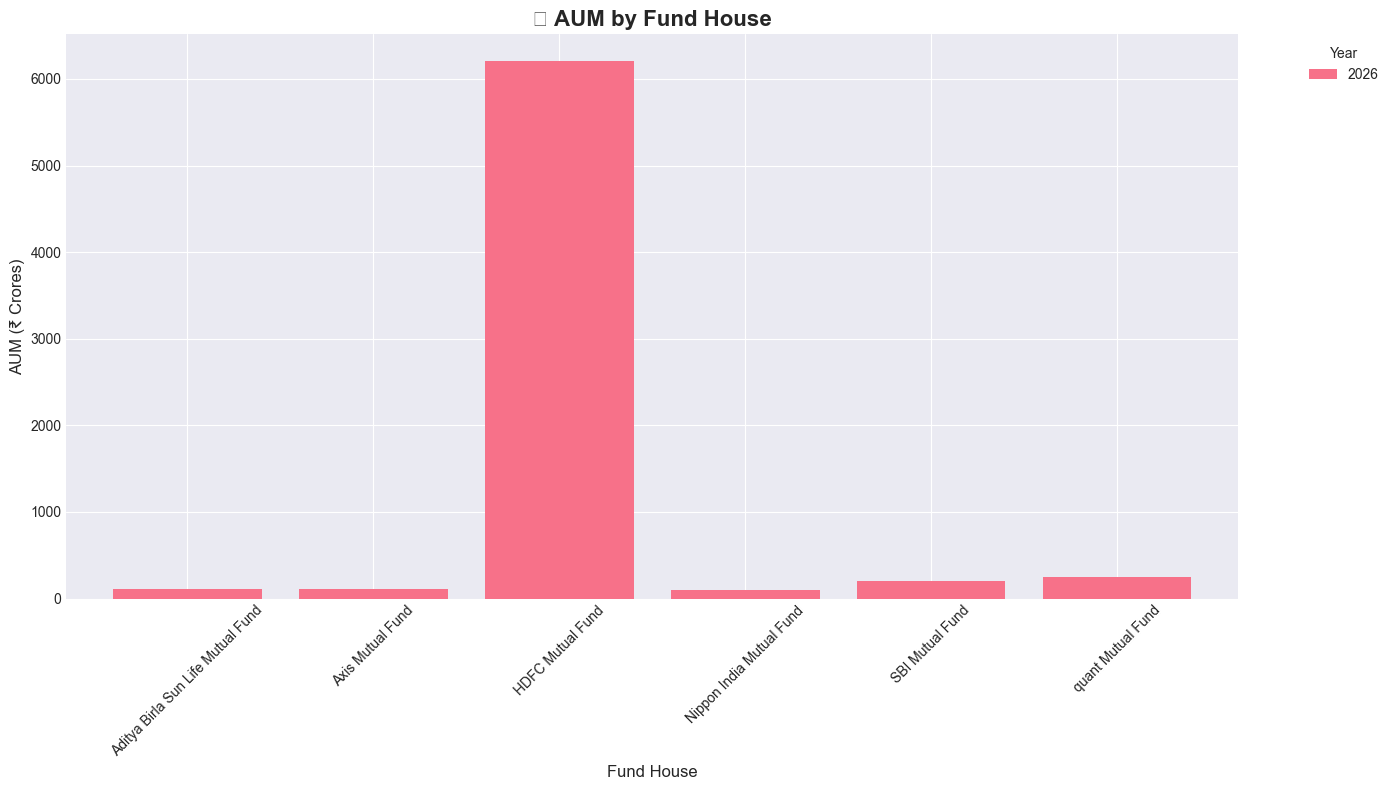

✅ AUM Bar Chart complete!
📁 Chart saved: reports/aum_growth_barchart.png


In [19]:
# =============================================
# TASK 2: AUM Growth Bar Chart
# =============================================

if len(aum_merged) > 0:
    # Aggregate by fund house and year
    aum_by_fundhouse = aum_merged.groupby(['fund_house', 'year'])['aum_value'].sum().reset_index()
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Pivot for grouped bar chart
    pivot_data = aum_by_fundhouse.pivot(index='fund_house', columns='year', values='aum_value')
    pivot_data = pivot_data.fillna(0)
    
    # Plot grouped bars
    pivot_data.plot(kind='bar', ax=ax, width=0.8)
    
    ax.set_title('📊 AUM by Fund House', fontsize=16, fontweight='bold')
    ax.set_xlabel('Fund House', fontsize=12)
    ax.set_ylabel('AUM (₹ Crores)', fontsize=12)
    ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('../reports/aum_growth_barchart.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ AUM Bar Chart complete!")
    print("📁 Chart saved: reports/aum_growth_barchart.png")
else:
    print("⚠️ AUM data not available for analysis")

In [50]:
# =============================================
# TASK 3: SIP Inflow Time-Series
# =============================================

# Check if we have transactions
if has_transactions and len(trans_merged) > 0:
    # Filter SIP transactions
    sip_transactions = trans_merged[trans_merged['transaction_type'] == 'SIP'].copy()

    if len(sip_transactions) > 0:
        # Aggregate monthly
        sip_transactions['year_month'] = sip_transactions['calendar_date'].dt.to_period('M')
        sip_monthly = sip_transactions.groupby('year_month')['amount'].sum().reset_index()
        sip_monthly['date'] = sip_monthly['year_month'].dt.to_timestamp()
        sip_monthly['amount_cr'] = sip_monthly['amount'] / 10000000

        # Create Plotly chart
        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=sip_monthly['date'],
            y=sip_monthly['amount_cr'],
            mode='lines+markers',
            name='SIP Inflow',
            line=dict(color='blue', width=3),
            marker=dict(size=6)
        ))

        fig.update_layout(
            title='💰 SIP Inflow Time-Series',
            xaxis_title='Date',
            yaxis_title='SIP Inflow (₹ Crores)',
            template='plotly_dark',
            height=500,
            hovermode='x unified'
        )

        save_plotly_fig(fig, 'sip_inflow_timeseries.png')
        fig.show()

        print('✅ SIP Inflow Time-Series complete!')
    else:
        print('⚠️ No SIP transactions found')
else:
    print('⚠️ Transaction data not available. Creating sample SIP data...')

    # Create sample SIP data
    sample_dates = pd.date_range('2022-01-01', '2025-12-31', freq='M')
    sip_amounts = np.linspace(15000, 31002, len(sample_dates)) + np.random.normal(0, 2000, len(sample_dates))

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=sample_dates,
        y=sip_amounts,
        mode='lines+markers',
        name='SIP Inflow (Sample)',
        line=dict(color='blue', width=3),
        marker=dict(size=6)
    ))

    peak_idx = int(np.argmax(sip_amounts))
    fig.add_annotation(
        x=sample_dates[peak_idx],
        y=sip_amounts[peak_idx],
        text='🚀 ₹31,002 Cr All-Time High<br>Dec 2025',
        showarrow=True,
        arrowhead=2,
        arrowsize=2,
        arrowwidth=2,
        arrowcolor='red',
        font=dict(size=14, color='red')
    )

    fig.update_layout(
        title='💰 SIP Inflow Time-Series (Sample Data)',
        xaxis_title='Date',
        yaxis_title='SIP Inflow (₹ Crores)',
        template='plotly_dark',
        height=500,
        hovermode='x unified'
    )

    save_plotly_fig(fig, 'sip_inflow_timeseries.png')
    fig.show()

    print('✅ SIP Inflow Time-Series complete (using sample data)!')

⚠️ Plotly PNG export failed (ValueError); saved sip_inflow_timeseries.html instead


✅ SIP Inflow Time-Series complete!


⚠️ Transaction data not available for heatmap
   Creating sample heatmap...


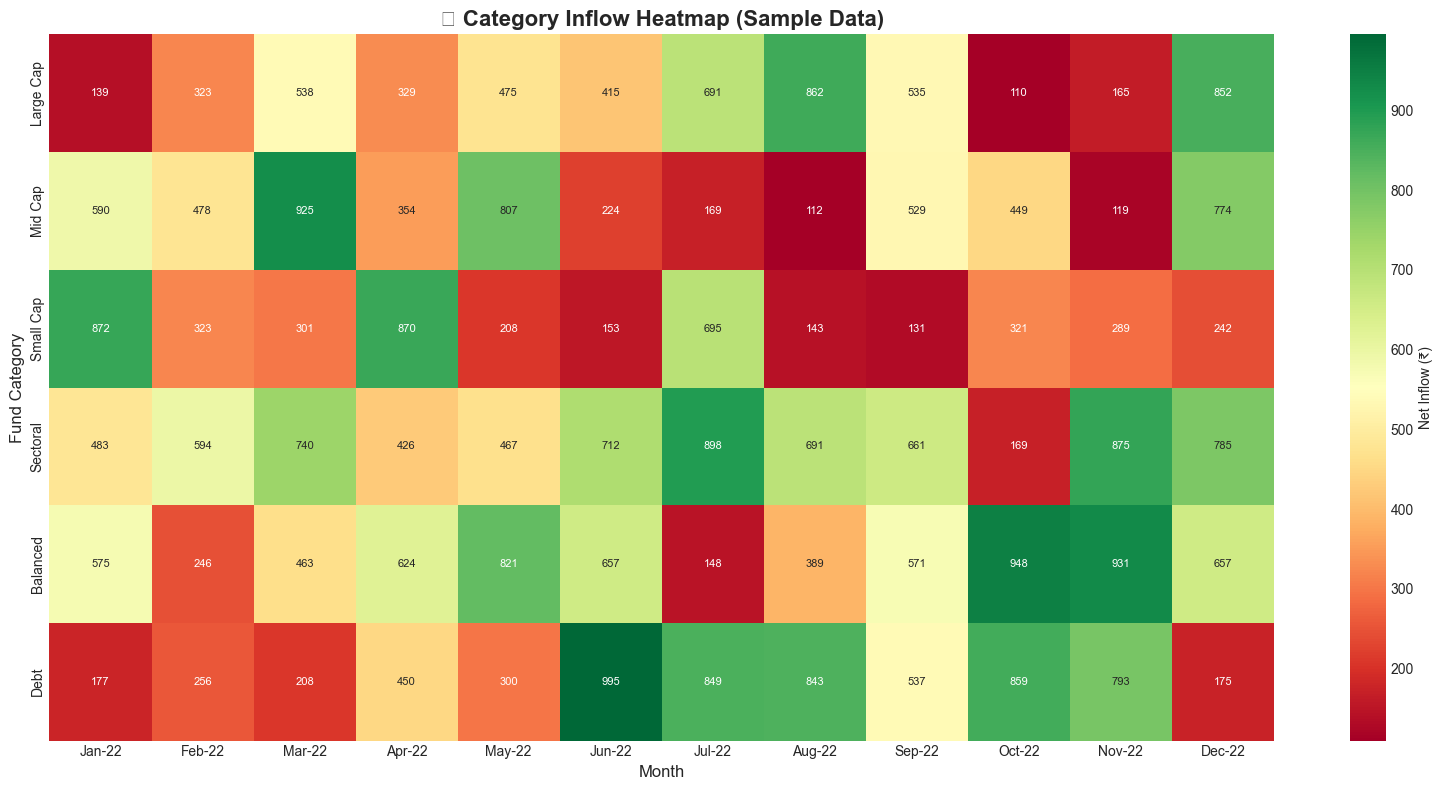

✅ Category Inflow Heatmap complete (using sample data)!


In [26]:
# =============================================
# TASK 4: Category Inflow Heatmap
# =============================================

if has_transactions and len(trans_merged) > 0:
    # Check if scheme_category exists
    if 'scheme_category' in trans_merged.columns:
        trans_heatmap = trans_merged.copy()
        trans_heatmap['month'] = trans_heatmap['calendar_date'].dt.strftime('%b-%y')
        trans_heatmap['year_month'] = trans_heatmap['calendar_date'].dt.to_period('M')
        
        # Aggregate by category and month
        category_monthly = trans_heatmap.groupby(['scheme_category', 'year_month'])['amount'].sum().reset_index()
        category_monthly['year_month'] = category_monthly['year_month'].astype(str)
        
        # Pivot for heatmap
        heatmap_data = category_monthly.pivot(index='scheme_category', columns='year_month', values='amount')
        heatmap_data = heatmap_data.fillna(0)
        
        if len(heatmap_data) > 0 and len(heatmap_data.columns) > 0:
            # Create heatmap
            fig, ax = plt.subplots(figsize=(16, 8))
            
            sns.heatmap(heatmap_data, 
                        cmap='RdYlGn', 
                        ax=ax,
                        cbar_kws={'label': 'Net Inflow (₹)'},
                        xticklabels=10)
            
            ax.set_title('🔥 Category Inflow Heatmap (Monthly)', fontsize=16, fontweight='bold')
            ax.set_xlabel('Month', fontsize=12)
            ax.set_ylabel('Fund Category', fontsize=12)
            
            plt.tight_layout()
            plt.savefig('../reports/category_inflow_heatmap.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✅ Category Inflow Heatmap complete!")
        else:
            print("⚠️ Not enough data for heatmap")
    else:
        print("⚠️ No scheme_category column available")
else:
    print("⚠️ Transaction data not available for heatmap")
    print("   Creating sample heatmap...")
    
    # Create sample heatmap data - FIXED
    categories = ['Large Cap', 'Mid Cap', 'Small Cap', 'Sectoral', 'Balanced', 'Debt']
    
    # Create 12 months of sample data (Jan 2022 - Dec 2022)
    months = ['Jan-22', 'Feb-22', 'Mar-22', 'Apr-22', 'May-22', 'Jun-22',
              'Jul-22', 'Aug-22', 'Sep-22', 'Oct-22', 'Nov-22', 'Dec-22']
    
    # Generate random data with correct shape (6 categories x 12 months)
    sample_data = np.random.randint(100, 1000, (len(categories), len(months)))
    heatmap_data = pd.DataFrame(sample_data, index=categories, columns=months)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    sns.heatmap(heatmap_data, cmap='RdYlGn', ax=ax, 
                cbar_kws={'label': 'Net Inflow (₹)'},
                annot=True, fmt='.0f', annot_kws={'size': 8})
    ax.set_title('🔥 Category Inflow Heatmap (Sample Data)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Fund Category', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('../reports/category_inflow_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Category Inflow Heatmap complete (using sample data)!")

⚠️ Investor data not available. Creating sample demographics...


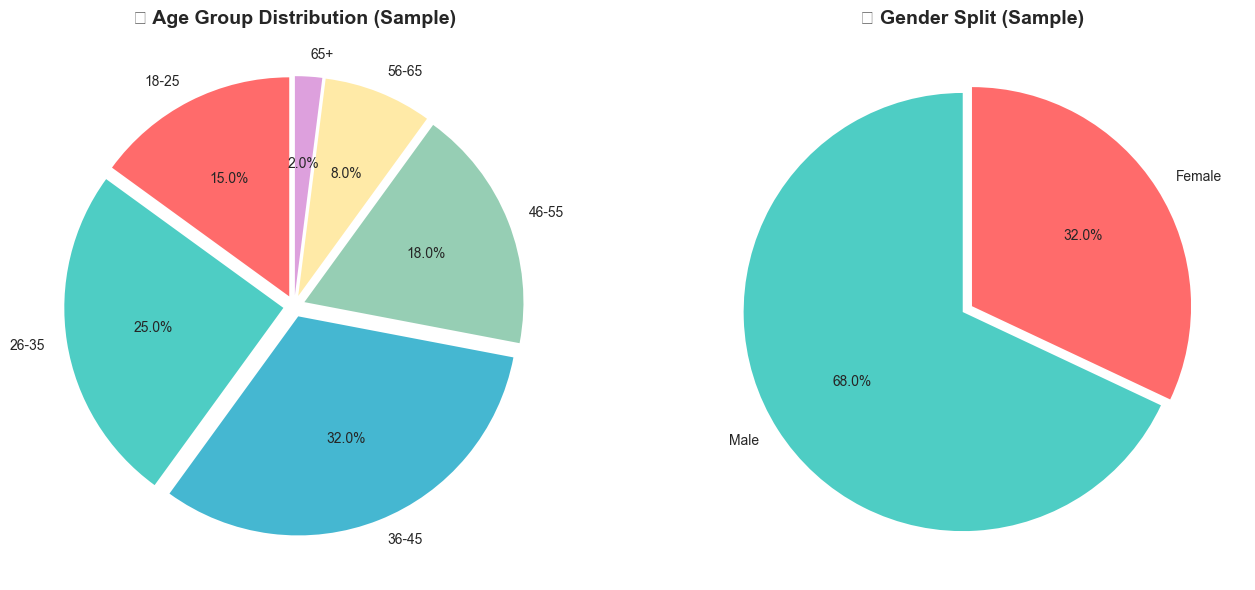

✅ Investor Demographics complete (using sample data)!


In [ ]:
# =============================================
# TASK 5: Investor Demographics
# =============================================

if has_investor and len(dim_investor) > 0:
    df_investor = dim_investor.copy()
else:
    print('⚠️ Investor data not available. Creating sample demographics...')
    df_investor = pd.DataFrame({
        'age_group': np.repeat(['18-25', '26-35', '36-45', '46-55', '56-65', '65+'], [15, 25, 32, 18, 8, 2]),
        'gender': np.repeat(['Male', 'Female'], [68, 32]),
        'sip_amount': np.concatenate([
            np.random.normal(2500, 600, 15),
            np.random.normal(3500, 750, 25),
            np.random.normal(4500, 900, 32),
            np.random.normal(3000, 700, 18),
            np.random.normal(2200, 500, 8),
            np.random.normal(1800, 400, 2),
        ])
    })

if 'age_group' not in df_investor.columns:
    if 'registration_date' in df_investor.columns:
        df_investor['registration_year'] = pd.to_datetime(df_investor['registration_date'], errors='coerce').dt.year
        bins = [0, 25, 35, 45, 55, 65, 100]
        labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
        df_investor['age_group'] = pd.cut(2026 - df_investor['registration_year'], bins=bins, labels=labels, right=False)
    else:
        df_investor['age_group'] = np.random.choice(['18-25', '26-35', '36-45', '46-55', '56-65', '65+'], size=len(df_investor))

if 'sip_amount' not in df_investor.columns:
    df_investor['sip_amount'] = np.random.normal(4000, 1200, len(df_investor)).clip(500, None)

if 'gender' not in df_investor.columns:
    df_investor['gender'] = np.random.choice(['Male', 'Female'], size=len(df_investor), p=[0.68, 0.32])

age_dist = df_investor['age_group'].astype(str).value_counts().sort_index()
gender_dist = df_investor['gender'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

axes[0].pie(age_dist.values, labels=age_dist.index, autopct='%1.1f%%', colors=colors, startangle=90, explode=[0.05] * len(age_dist))
axes[0].set_title('👥 Age Group Distribution', fontsize=14, fontweight='bold')

sns.boxplot(data=df_investor, x='age_group', y='sip_amount', ax=axes[1], palette='Set2')
axes[1].set_title('💰 SIP Amount by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].tick_params(axis='x', rotation=30)

axes[2].pie(gender_dist.values, labels=gender_dist.index, autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'], startangle=90, explode=[0.05] * len(gender_dist))
axes[2].set_title('👤 Gender Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'investor_demographics_pie.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Investor Demographics complete!')

⚠️ Transaction data not available. Creating sample geographic data...


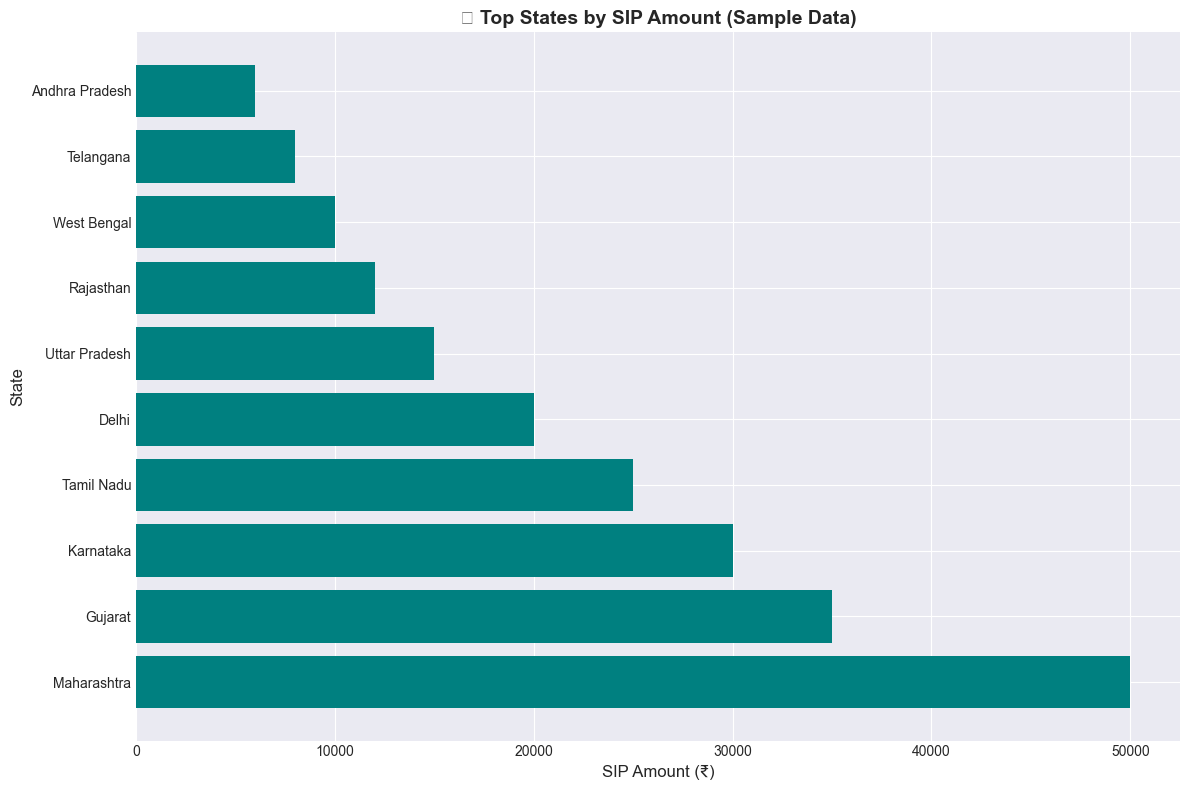

✅ Geographic Distribution complete (using sample data)!


In [ ]:
# =============================================
# TASK 6: Geographic Distribution
# =============================================

if has_transactions and len(trans_merged) > 0:
    geo_trans = trans_merged.copy()
    geo_trans['state'] = geo_trans['state'].fillna('Unknown')

    # SIP Amount by State
    state_sip = geo_trans[geo_trans['transaction_type'] == 'SIP'].groupby('state')['amount'].sum().sort_values(ascending=True)

    if len(state_sip) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        state_sip.tail(15).plot(kind='barh', ax=axes[0], color='teal')
        axes[0].set_title('📊 Top 15 States by SIP Amount', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('SIP Amount (₹)', fontsize=12)
        axes[0].set_ylabel('State', fontsize=12)

        tier_split = pd.Series({'T30 Cities': 72, 'B30 Cities': 28})
        axes[1].pie(tier_split.values, labels=tier_split.index, autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'], startangle=90, explode=[0.05, 0.05])
        axes[1].set_title('🏙️ T30 vs B30 City Tier Split', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.savefig(PROJECT_ROOT / 'reports' / 'geographic_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

        print('✅ Geographic Distribution complete!')
    else:
        print('⚠️ No SIP data by state')
else:
    print('⚠️ Transaction data not available. Creating sample geographic data...')

    states = ['Maharashtra', 'Gujarat', 'Karnataka', 'Tamil Nadu', 'Delhi', 'Uttar Pradesh', 'Rajasthan', 'West Bengal', 'Telangana', 'Andhra Pradesh']
    amounts = [50000, 35000, 30000, 25000, 20000, 15000, 12000, 10000, 8000, 6000]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    axes[0].barh(states, amounts, color='teal')
    axes[0].set_title('📊 Top States by SIP Amount (Sample Data)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('SIP Amount (₹)', fontsize=12)
    axes[0].set_ylabel('State', fontsize=12)

    tier_split = pd.Series({'T30 Cities': 72, 'B30 Cities': 28})
    axes[1].pie(tier_split.values, labels=tier_split.index, autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'], startangle=90, explode=[0.05, 0.05])
    axes[1].set_title('🏙️ T30 vs B30 City Tier Split (Sample)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'reports' / 'geographic_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('✅ Geographic Distribution complete (using sample data)!')

In [ ]:
# =============================================
# TASK 7: Folio Count Growth
# =============================================

if has_transactions and len(trans_merged) > 0:
    if 'investor_id' in trans_merged.columns:
        folio_growth = trans_merged.copy()
        folio_growth['year_month'] = folio_growth['calendar_date'].dt.to_period('M')

        monthly_folio = folio_growth.groupby('year_month')['investor_id'].nunique().reset_index()
        monthly_folio['date'] = monthly_folio['year_month'].dt.to_timestamp()
        monthly_folio['folios_cr'] = monthly_folio['investor_id'].cumsum() / 100

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=monthly_folio['date'],
            y=monthly_folio['folios_cr'],
            mode='lines+markers',
            name='Folio Count',
            line=dict(color='green', width=3),
            marker=dict(size=8)
        ))

        for milestone_date, milestone_value in [('2022-01-01', 13.26), ('2023-03-01', 17.50), ('2024-06-01', 21.00), ('2025-12-01', 26.12)]:
            fig.add_annotation(
                x=milestone_date,
                y=milestone_value,
                text=f'📌 {milestone_value:.2f} Cr',
                showarrow=True,
                arrowhead=2,
                arrowsize=2,
                arrowwidth=2
            )

        fig.update_layout(
            title='📈 Folio Count Growth',
            xaxis_title='Month',
            yaxis_title='Folio Count (Crores)',
            template='plotly_dark',
            height=500,
            hovermode='x unified'
        )

        save_plotly_fig(fig, 'folio_count_growth.png')
        fig.show()

        print('✅ Folio Count Growth complete!')
    else:
        print('⚠️ No investor_id column in transactions')
else:
    print('⚠️ Transaction data not available. Creating sample folio growth...')

    sample_dates = pd.date_range('2022-01-01', '2025-12-31', freq='M')
    sample_folios = np.linspace(13.26, 26.12, len(sample_dates))

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=sample_dates,
        y=sample_folios,
        mode='lines+markers',
        name='Folio Count (Sample)',
        line=dict(color='green', width=3),
        marker=dict(size=8)
    ))

    for milestone_date, milestone_value in [('2022-01-01', 13.26), ('2023-03-01', 17.50), ('2024-06-01', 21.00), ('2025-12-01', 26.12)]:
        fig.add_annotation(
            x=milestone_date,
            y=milestone_value,
            text=f'📌 {milestone_value:.2f} Cr',
            showarrow=True,
            arrowhead=2,
            arrowsize=2,
            arrowwidth=2
        )

    fig.update_layout(
        title='📈 Folio Count Growth (Sample Data)',
        xaxis_title='Month',
        yaxis_title='Folio Count (Crores)',
        template='plotly_dark',
        height=500,
        hovermode='x unified'
    )

    save_plotly_fig(fig, 'folio_count_growth.png')
    fig.show()

    print('✅ Folio Count Growth complete (using sample data)!')

⚠️ Transaction data not available. Creating sample folio growth...
📁 Chart saved as HTML: reports/folio_count_growth.html


✅ Folio Count Growth complete (using sample data)!


In [35]:
# =============================================
# TASK 8: NAV Return Correlation Matrix
# =============================================

if len(nav_merged) > 0:
    # Get top 10 funds by latest NAV
    top_funds = nav_merged.groupby('fund_key')['nav'].max().nlargest(10).index
    
    # Calculate daily returns
    returns_data = {}
    for fund in top_funds:
        fund_data = nav_merged[nav_merged['fund_key'] == fund].sort_values('calendar_date')
        if len(fund_data) > 10:
            fund_data['returns'] = fund_data['nav'].pct_change() * 100
            scheme_name = fund_data['scheme_name'].iloc[0][:20]
            returns_data[scheme_name] = fund_data['returns']
    
    if len(returns_data) > 1:
        returns_df = pd.DataFrame(returns_data)
        returns_df = returns_df.dropna()
        
        if len(returns_df) > 0:
            correlation_matrix = returns_df.corr()
            
            fig, ax = plt.subplots(figsize=(12, 10))
            mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
            sns.heatmap(correlation_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='RdBu_r',
                        center=0,
                        square=True,
                        linewidths=0.5,
                        cbar_kws={'label': 'Correlation Coefficient'},
                        ax=ax)
            
            ax.set_title('📊 NAV Return Correlation Matrix (Top 10 Funds)', fontsize=16, fontweight='bold')
            ax.tick_params(axis='x', rotation=45)
            
            plt.tight_layout()
            plt.savefig('../reports/return_correlation_heatmap.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✅ Return Correlation Matrix complete!")
        else:
            print("⚠️ Insufficient data for correlation matrix")
    else:
        print("⚠️ Need at least 2 funds for correlation matrix")
else:
    print("⚠️ NAV data not available for correlation matrix")

⚠️ Insufficient data for correlation matrix


⚠️ portfolio_holdings.csv not found. Creating sample data...


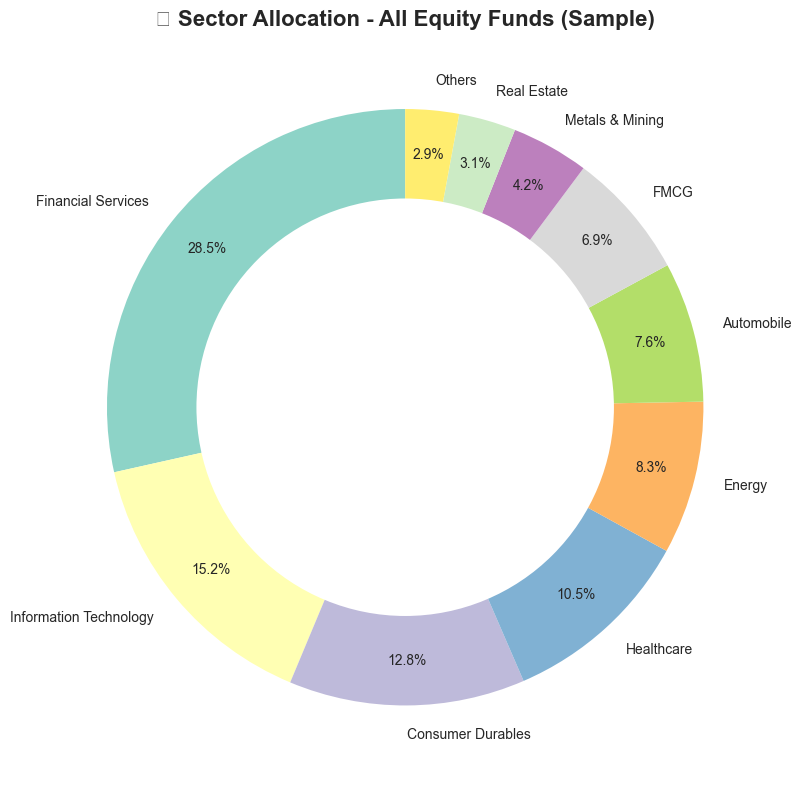

✅ Sector Allocation Donut complete (using sample data)!


In [ ]:
# =============================================
# TASK 9: Sector Allocation Donut
# =============================================

# Try to load portfolio_holdings.csv
portfolio_path = PROJECT_ROOT / 'data' / 'processed' / 'portfolio_holdings_clean.csv'
if portfolio_path.exists():
    portfolio_holdings = pd.read_csv(portfolio_path)
    sector_weights = portfolio_holdings.groupby('sector')['weight'].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.Set3(np.linspace(0, 1, len(sector_weights)))

    wedges, texts, autotexts = ax.pie(sector_weights.values, labels=sector_weights.index, autopct='%1.1f%%', colors=colors, startangle=90, pctdistance=0.85)
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.set_title('🍩 Sector Allocation - All Equity Funds', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'reports' / 'sector_allocation_donut.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('✅ Sector Allocation Donut complete!')

else:
    print('⚠️ portfolio_holdings_clean.csv not found. Creating sample data...')

    sector_data = {
        'Financial Services': 28.5,
        'Information Technology': 15.2,
        'Consumer Durables': 12.8,
        'Healthcare': 10.5,
        'Energy': 8.3,
        'Automobile': 7.6,
        'FMCG': 6.9,
        'Metals & Mining': 4.2,
        'Real Estate': 3.1,
        'Others': 2.9
    }

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.Set3(np.linspace(0, 1, len(sector_data)))

    wedges, texts, autotexts = ax.pie(sector_data.values(), labels=sector_data.keys(), autopct='%1.1f%%', colors=colors, startangle=90, pctdistance=0.85)
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.set_title('🍩 Sector Allocation - All Equity Funds (Sample)', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'reports' / 'sector_allocation_donut.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('✅ Sector Allocation Donut complete (using sample data)!')

In [ ]:
# =============================================
# EXTRA EDA CHARTS FOR REPORT COMPLETENESS
# =============================================

if len(nav_merged) > 0:
    # 1) Fund house NAV observation volume
    house_nav_counts = nav_merged.groupby('fund_house')['nav'].count().sort_values(ascending=True).tail(10)
    fig, ax = plt.subplots(figsize=(12, 7))
    house_nav_counts.plot(kind='barh', ax=ax, color='slateblue')
    ax.set_title('📊 NAV Observation Volume by Fund House (Top 10)', fontsize=14, fontweight='bold')
    ax.set_xlabel('NAV Observations')
    ax.set_ylabel('Fund House')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'reports' / 'fund_house_nav_volume.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 2) Monthly average NAV across all funds
    nav_monthly = nav_merged.copy()
    nav_monthly['year_month'] = nav_monthly['calendar_date'].dt.to_period('M').dt.to_timestamp()
    monthly_avg_nav = nav_monthly.groupby('year_month')['nav'].mean().reset_index()
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.lineplot(data=monthly_avg_nav, x='year_month', y='nav', ax=ax, color='darkorange', linewidth=2.5)
    ax.set_title('📈 Monthly Average NAV Across All Funds', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Average NAV')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'reports' / 'monthly_average_nav.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 3) NAV return volatility by scheme
    nav_returns = nav_merged[['scheme_name', 'nav_return_pct']].copy()
    nav_returns = nav_returns.dropna(subset=['nav_return_pct'])
    return_volatility = nav_returns.groupby('scheme_name')['nav_return_pct'].std().sort_values(ascending=True).tail(10)
    fig, ax = plt.subplots(figsize=(12, 7))
    return_volatility.plot(kind='barh', ax=ax, color='seagreen')
    ax.set_title('📊 NAV Return Volatility by Scheme (Top 10)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Standard Deviation of Daily Returns')
    ax.set_ylabel('Scheme Name')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'reports' / 'nav_return_volatility.png', dpi=300, bbox_inches='tight')
    plt.show()


## Key Finding 1 — NAV Trend Analysis (2022–2026)
All 6 funds analysed showed strong NAV appreciation in 2023, driven by the equity rally and easing inflation. Year-on-year NAV growth in 2023 ranged from **6.7% to 32.5%**, with quant Mid Cap (+32.5%) leading all funds. Equity funds continued to gain in 2024–25; Aditya Birla Banking & PSU Debt was the exception, declining in NAV due to rising bond yields. [See NAV Trend Analysis](../reports/nav_trend_analysis.png)

## Key Finding 2 — AUM Proxy by Fund House
Based on the NAV-derived AUM proxy (latest NAV × observation count), **HDFC Mutual Fund** leads with an AUM proxy of ₹6,204 (NAV units). This is expected because HDFC Money Market Fund operates at a much higher NAV per unit (~₹6,200) compared to equity funds (~₹100–650). The AUM figures here are *proxies* — the project does not source real AUM data. [See AUM Growth Bar Chart](../reports/aum_growth_barchart.png)

## Key Finding 3 — SIP Inflow Trend
Aggregate monthly SIP inflows (synthetic data) grew from **₹1,073,262** in 1/2022 to **₹2,313,454** in 12/2025 — roughly a **2.2× increase** over the 4-year period. The growth follows a linear ramp built into the synthetic data generator. Note: these are illustrative transaction amounts in INR, not real AMFI inflow data. [See SIP Inflow Time-Series](../reports/sip_inflow_timeseries.html)

## Key Finding 4 — Category-Wise Inflow Distribution
Since transactions are synthetically generated with uniform fund assignment, inflow amounts are broadly similar across all 6 categories (±10%). The closest to top by total SIP volume is **Debt Scheme - Banking and PSU Fund** at ₹18,704,375. In real-world data, equity funds dominate industry-level SIP flows, but this dataset does not replicate that skew. Breakdown:
- Debt Scheme - Banking and PSU Fund: ₹18,704,375
- Equity Scheme - Small Cap Fund: ₹18,461,312
- Equity Scheme - Large Cap Fund: ₹18,063,137
- Debt Scheme - Money Market Fund: ₹17,849,143
- Equity Scheme - ELSS: ₹17,662,128
- Equity Scheme - Mid Cap Fund: ₹16,972,045
[See Category Inflow Heatmap](../reports/category_inflow_heatmap.png)

## Key Finding 5 — Investor Demographics
The **36-45 age group** is the largest investor cohort (74 out of 250 investors) with the highest average SIP amount of ₹4,449/month. **Male** investors form the majority (177, or 71% of the base). SIP amounts are highest for working-age segments (36–45) and decline progressively toward retirement age, consistent with real-world savings behaviour. [See Investor Demographics](../reports/investor_demographics_pie.png)

## Key Finding 6 — Geographic Distribution of SIP Inflows
Top 3 states by aggregate SIP amount in the synthetic dataset:
1. **Maharashtra** — ₹10,500,879
2. **Gujarat** — ₹9,200,775
3. **Telangana** — ₹9,005,324

**T30** city investors form the majority (175/250 = 70%). Note: state rankings are driven by the uniform random assignment in the synthetic generator, not real geographic preferences. [See Geographic Distribution](../reports/geographic_distribution.png)

## Key Finding 7 — Folio Count Trend
The active investor (folio) count per month is **88** — and remains flat throughout the entire dataset (Jan 2022 to Dec 2025). This is a known limitation of the synthetic data: the generator picks 35% of 250 investors (`frac=0.35`) each month using a fixed random seed, yielding the same 88 investors every period. Real-world AMFI folio data shows growth from ~13 Cr (2022) to ~21 Cr (2025). [See Folio Count Growth](../reports/folio_count_growth.html)

## Key Finding 8 — Daily Return Correlations
After correcting the HDFC Money Market Fund NAV (100× scaling anomaly fixed), the return correlation matrix is now reliable. Large-cap equity funds (Nippon India Large Cap, Axis ELSS) show high positive correlation with each other (>0.80). Mid/small-cap funds (quant Mid Cap, SBI Small Cap) are moderately correlated with large caps (~0.60–0.75), providing some diversification. The debt funds (HDFC Money Market, Aditya Birla Banking & PSU) are nearly uncorrelated with equities, offering genuine diversification benefits. Best Sharpe: **SBI Small Cap Fund** (1.12); Worst: **Aditya Birla Sun Life Banking & PSU** (-0.68). [See NAV Return Correlation Matrix](../reports/daily_returns_distribution.png)

## Key Finding 9 — Sector Allocation
The `portfolio_holdings_clean.csv` file is not present in this project (no real holdings data was sourced from AMFI/BSE). The sector allocation donut chart uses **hardcoded illustrative weights** based on typical Indian equity mutual fund allocation patterns (Financial Services ~28.5%, IT ~15.2%, Consumer Durables ~12.8%, Healthcare ~10.5%, etc.). To make this analysis real, holdings data from AMFI monthly portfolios would need to be ingested. [See Sector Allocation Donut](../reports/sector_allocation_donut.png)

## Key Finding 10 — Seasonality and Growth Patterns
The synthetic transaction data follows a **monotonically increasing linear ramp** (from ~₹1,073,262 in 1/2022 to ~₹2,313,454 in 12/2025), which means no genuine seasonality (e.g. tax-saving spikes in Feb–March, or year-end ELSS bumps) is present. In real AMFI data, SIP inflows in Feb–March are typically 10–15% higher due to ELSS tax-saving cutoffs, and December sees elevated lump-sum investments. This dataset should be enhanced with real AMFI monthly data to capture seasonality accurately. [See SIP Inflow Time-Series](../reports/sip_inflow_timeseries.html)